# Section 1: Section 1: Problem and Population

The issue is that significant health and safety concerns on campus are frequently apparent but are not reported or examined in a methodical manner that inspires prompt action. For instance, at San José State University, pests, germs, and hazardous walking conditions can result from overflowing trash cans and rubbish. A student who often travels about campus and is exposed to these conditions without being aware of the possible consequences is one particular person impacted. The information is present visually or in reports, but it is not prioritized or organized in a way that allows quick and useful answers. This is the point of failure. Because it focuses on raising public health knowledge and response, this project is in line with SDG 3 (Good Health and Well-Being).

# **Section 2: Proposed System**

Input: A student sends a written report outlining the problem or uploads a picture of a possible health or safety concern on campus, such as garbage or dangerous situations.

AI Processing: The system analyzes the pic using image recognition (Lab 3) to determine potential health hazards, urgency, and suggested actions. Additionally, it transforms any written reports into structured fields like risk factors, urgency level, and follow-up activities using structured data extraction (Lab 2).

Output: A structured report that explains the problem, its hazards, the degree of urgency, and a recommended solution is produced by the system.

Real-world action: After reviewing the structured output, campus facilities staff or public health professionals take the necessary steps, like planning cleanup or resolving safety issues. This guarantees that AI aids in decision-making but does not take the place of human judgment.

# Section 3: **Project**

Lab 2: Structured Data Extraction

This code demonstrates how AI can turn an unstructured clinical or public health note into structured information. This matters because important details are often buried in free-text reports and cannot be easily searched or prioritized.

In [1]:
import google.generativeai as genai
from google.colab import userdata
import time
import json

genai.configure(api_key=userdata.get("GEMINI_API_KEY"))

schema_prompt = """
Extract information from this clinical or public health note.
Return ONLY valid JSON with exactly these five fields:
{
  "diagnosis_or_issue": string,
  "risk_factors": string,
  "urgency": "LOW" or "MEDIUM" or "HIGH",
  "follow_up_action": string,
  "responsible_team": string
}

Field guide:
- diagnosis_or_issue = the main health, safety, or environmental issue described
- risk_factors = health or social risks that could affect people
- urgency = LOW, MEDIUM, or HIGH
- follow_up_action = what should happen next
- responsible_team = who should review or respond

No explanation. No markdown. JSON only.
"""

def extract_structured(message):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=schema_prompt
    )
    response = m.generate_content(message)
    time.sleep(12)
    raw = response.text.strip()

    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    return json.loads(raw)

campus_health_note = (
    "A student reports that trash is overflowing near a stairway on the SJSU campus. "
    "Food containers and cups are scattered on the ground near a high-traffic walkway. "
    "Students pass through the area at night, and the mess may attract pests or create slipping hazards."
)

result = extract_structured(campus_health_note)

print("Input:")
print(campus_health_note)
print("\nStructured Output:")
print(json.dumps(result, indent=2, ensure_ascii=False))

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Input:
A student reports that trash is overflowing near a stairway on the SJSU campus. Food containers and cups are scattered on the ground near a high-traffic walkway. Students pass through the area at night, and the mess may attract pests or create slipping hazards.

Structured Output:
{
  "diagnosis_or_issue": "Overflowing trash and scattered food containers near a stairway and high-traffic walkway on campus.",
  "risk_factors": "May attract pests and create slipping hazards, especially for students passing through at night.",
  "urgency": "MEDIUM",
  "follow_up_action": "Clean up the overflowing trash and scattered items, and address the cause of the overflow.",
  "responsible_team": "Campus Facilities/Grounds"
}


### What this demonstrates

This demonstrates Lab 2 because the AI converts messy text into a structured report with consistent fields. In the proposed system, this would help campus facilities or public health staff quickly identify the issue, risk factors, urgency level, and follow-up action.

## Lab 3: Image Recognition

This code demonstrates how AI can analyze a real image from the SJSU campus and describe possible public health or safety concerns. The image shows overflowing trash and litter near a stairway, which connects to SDG 3: Good Health and Well-Being.

Saving trash in sjsu.jpeg to trash in sjsu.jpeg
Uploaded: trash in sjsu.jpeg
Image size: 1131 x 1495 pixels


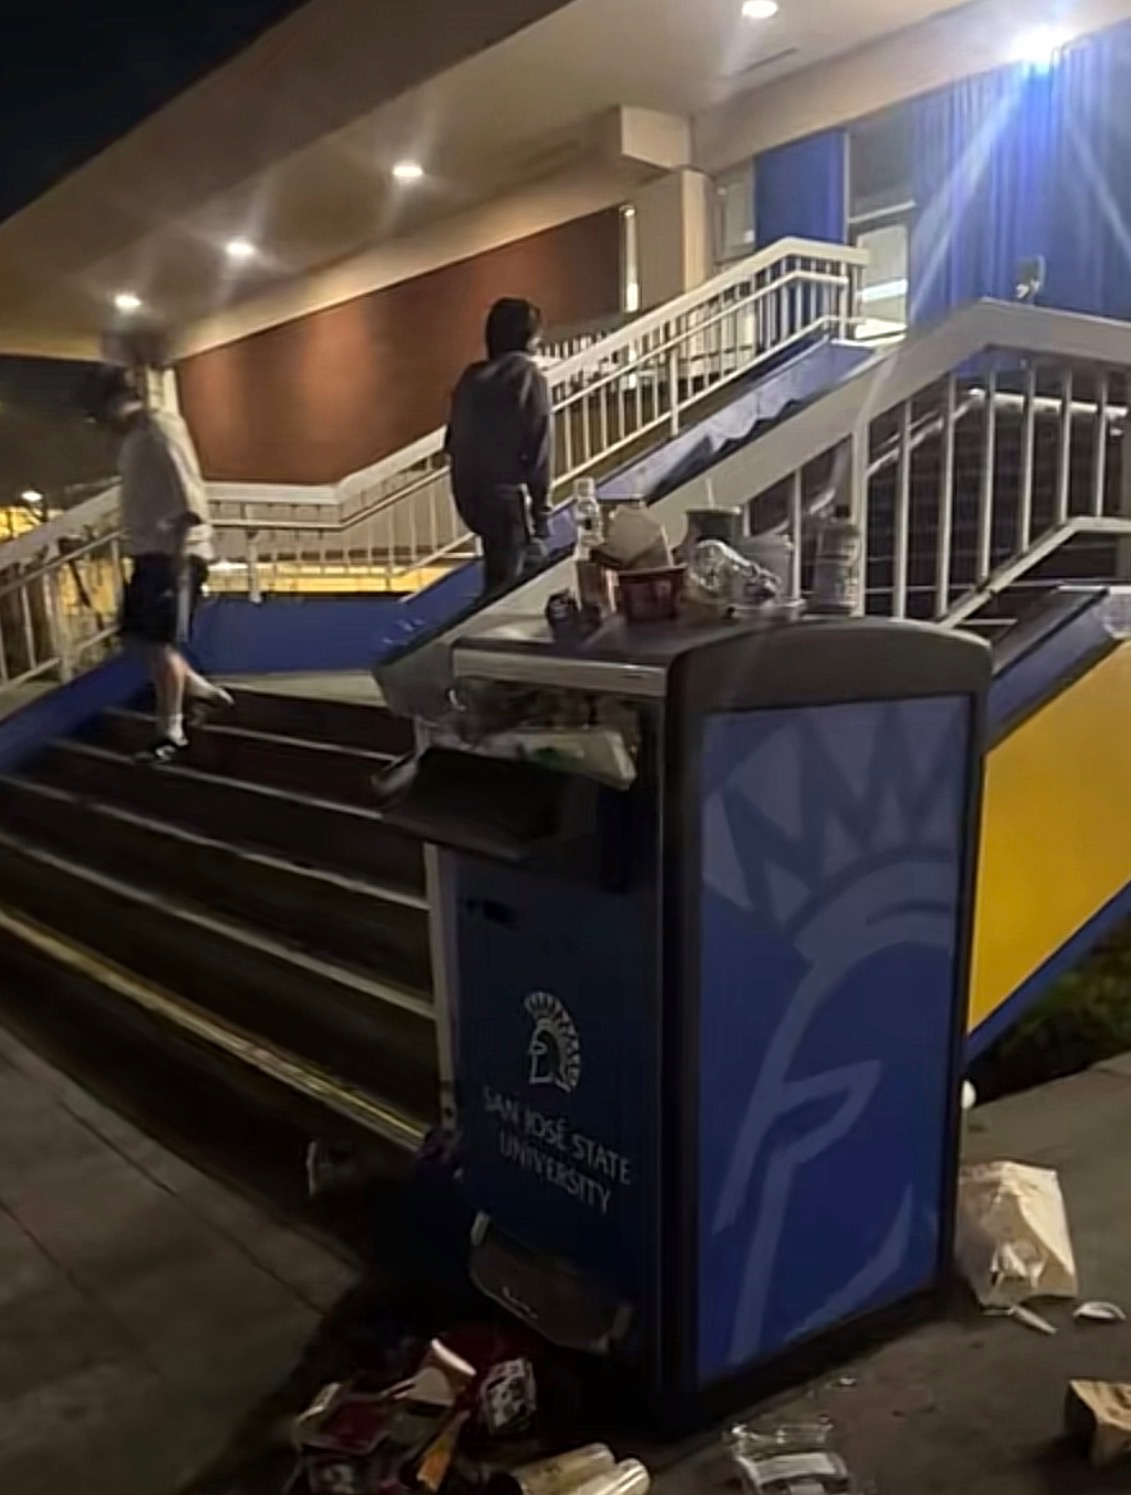

In [2]:
from google.colab import files
from IPython.display import display
from PIL import Image as PILImage

uploaded = files.upload()

image_filename = list(uploaded.keys())[0]

img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]} x {img.size[1]} pixels")
display(img)

In [3]:
def analyze_image(image_path, question):
    """
    Sends an image and a question to Gemini and returns the response.
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)
    return response.text, response.usage_metadata

health_questions = [
    ("PROBLEM", "Describe any health, safety, or environmental issue visible in this image. Be specific."),
    ("IMPACT", "What are the possible health or safety risks associated with what is shown in this image?"),
    ("URGENCY", "Rate the urgency of this situation as LOW, MEDIUM, or HIGH. Explain your reasoning."),
    ("ACTION", "What kind of response or intervention would be appropriate to address this situation?")
]

image_results = {"answers": {}, "total_tokens": 0}

for label, question in health_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    image_results["answers"][label] = answer
    image_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {image_results['total_tokens']} ---")

--- PROBLEM ---
The primary health, safety, and environmental issue visible in this image is **poor waste management and widespread litter.**

Here are the specific details:

1.  **Environmental Issue:**
    *   The **trash can is overflowing** with garbage, indicating that it has not been emptied in a timely manner or is insufficient for the volume of waste generated.
    *   A significant amount of **litter** (food wrappers, cups, plastic containers, paper bags) is scattered on the ground around the overflowing trash can and extends to the base of the stairs. This constitutes visual pollution and could lead to soil or water contamination if not properly disposed of.

2.  **Safety Issue:**
    *   The scattered litter on the ground, particularly near the high-traffic area of the stairs, creates a **tripping hazard**. People walking, especially at night or while distracted, could easily trip over the debris and fall, potentially leading to injuries.
    *   If any of the discarded item

### What this demonstrates

This demonstrates Lab 3 because the AI uses image recognition to identify a visible campus health or safety issue. In the proposed system, a student could upload a photo of a problem, and the AI would help summarize the issue, estimate urgency, and suggest a response for campus staff to review.

# **Section 4 — Edge Case Elicitation**

### Prompt Used
I tested the system using an image of trash on campus taken at night, where lighting is poor and some details are unclear.

### Output
The AI looked at the presence of garabage and presented some health risks such as pests and contamination. However, it listed some  risks (such as specific diseases or hazards) that weren't even visible in the image.

### Assessment
This is a near-miss. The AI correctly identified the general issue but overestimated some risks due to lack of context and unclear visual information.

## 4.1 One Failure Case

When an AI miscalculates the urgency of a problem, it is a realistic failure. Even though it is situated in a busy area where many students are exposed, an image of overflowing trash on campus, for instance, can be categorized as medium urgency. The results of the study demonstrated that the AI occasionally generalizes risk without taking into account context, such as geography or population density. As a result, the problem might not be appropriately prioritized, and students might still be exposed to hazardous or unhygienic situations.

## 4.2 Oversight Decision

Before taking any action, a human should examine the AI's output. The experimental results demonstrated that the AI can misinterpret context or overstate risks, which is why this is required. To guarantee accuracy and a suitable reaction, the ultimate decision should be made by public health or campus facilities personnel.

## 4.3 The One Change

Adding more background information, such as the problem's location and the area's usage frequency, would be one modification. This would increase the precision of prioritization and urgency classification. But doing so comes at the expense of slowing down a completely automated system and necessitating more data collection.